In [22]:
%matplotlib inline
from datascience import *
import numpy as np
import matplotlib.pyplot as plt

In [23]:
stud_temp = Table.read_table("student_temp.csv")

In [24]:
stud_temp

Date,Outdoor Temp (Celsius),Students at Lecture
June 21,28,435
June 22,30,417
June 23,34,394
June 24,36,398
June 27,34,410
June 28,26,385
June 29,26,370
June 30,28,373


In [25]:
stud_temp.drop("Date").group('Outdoor Temp (Celsius)', np.mean)


Outdoor Temp (Celsius),Students at Lecture mean
26,377.5
28,404
30,417
34,402
36,398


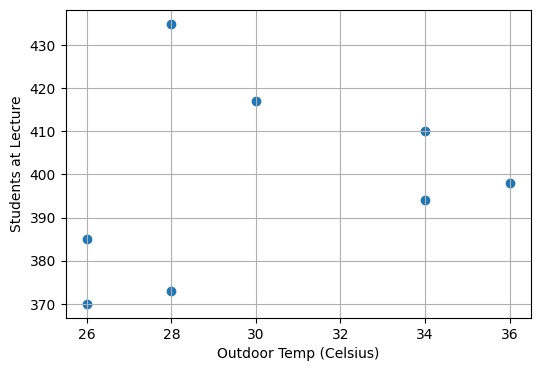

In [26]:
# Convert columns to numeric arrays (safe for plotting)
x = np.array(stud_temp.column('Outdoor Temp (Celsius)'), dtype=float)
y = np.array(stud_temp.column('Students at Lecture'), dtype=float)
plt.figure(figsize=(6,4))
plt.scatter(x, y, color='tab:blue')
plt.xlabel('Outdoor Temp (Celsius)')
plt.ylabel('Students at Lecture')
plt.grid(True)
plt.show()

In [32]:
temp_in_celsius = stud_temp.column("Outdoor Temp (Celsius)")
temp_in_farh = ((9/5)*temp_in_celsius) + 32

In [33]:
stud_temp = stud_temp.with_column(
    "Outdoor Temp (Farheihheit)", temp_in_farh
)

In [34]:
stud_temp

Date,Outdoor Temp (Celsius),Students at Lecture,Outdoor Temp (Farheihheit)
June 21,28,435,82.4
June 22,30,417,86
June 23,34,394,93.2
June 24,36,398,96.8
June 27,34,410,93.2
June 28,26,385,78.8
June 29,26,370,78.8
June 30,28,373,82.4


In [40]:
method = ["Take the Bus to Work", "Drive to Work"]
cowork = [12, 15]
coffee = [1.1, 1.9]

cofmat = Table().with_columns(
    "Method", method,
    "Coworkers", cowork,
    "Coffee",  coffee
)

In [41]:
cofmat

Method,Coworkers,Coffee
Take the Bus to Work,12,1.1
Drive to Work,15,1.9


In [43]:
bus = cofmat.where(method, "Take the Bus to Work")
drive = cofmat.where(method, "Drive to Work")

difference = abs((bus.column("Coworkers")*bus.column("Coffee") * 365) - (drive.column("Coworkers")*drive.column("Coffee") * 365))
difference

array([ 5584.5])